C:\Users\DELL\AppData\Local\Temp\ipykernel_14272\1950684487.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=intent_counts, x="Ý định (Intent)", y="Số lượng câu hỏi", palette="magma")


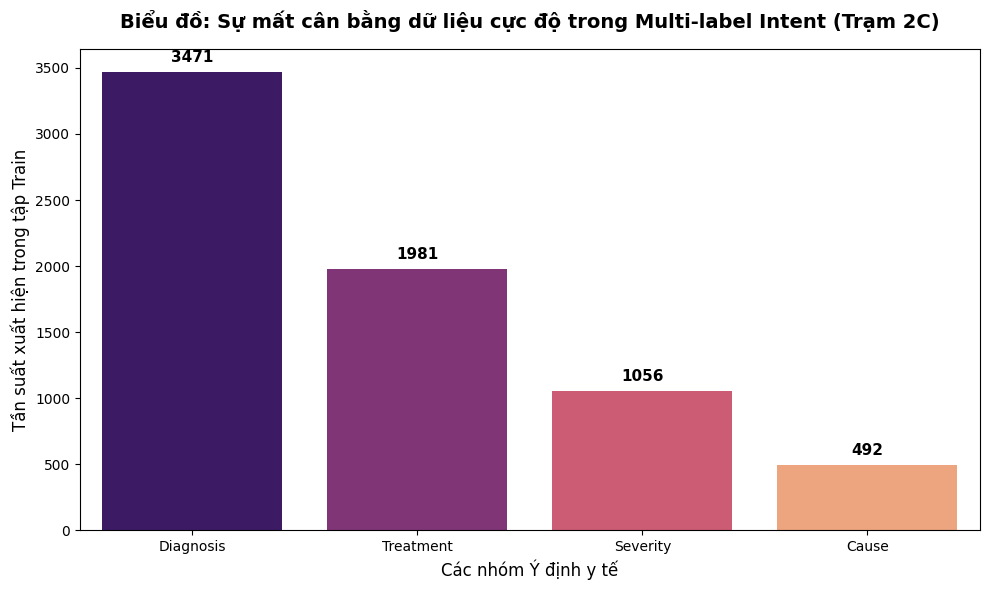

✅ Đã lưu thành công: D:/năm 3/hk2/data mining and explore skibidi/project/Medical-NLU-Pipeline/reports/figures/intent_imbalance.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
# 1. Đọc và chuẩn hóa dữ liệu Intent thực tế
intents_list = []
with open("D:/năm 3/hk2/data mining and explore skibidi/project/Medical-NLU-Pipeline/data/intent_train.json", "r", encoding="utf-8") as f:
    data = json.load(f)
    samples = data if isinstance(data, list) else data.get("data", [])

# Sử dụng logic chuẩn hóa giống y hệt trong data_loader.py
for sample in samples:
    raw_intents = sample.get("labels", sample.get("intents", sample.get("intent", [])))
    if isinstance(raw_intents, str): raw_intents = [raw_intents]
    
    for intent in raw_intents:
        intent_lower = intent.lower()
        if "diagnosis" in intent_lower: intents_list.append("Diagnosis")
        elif "severity" in intent_lower: intents_list.append("Severity")
        elif "treatment" in intent_lower: intents_list.append("Treatment")
        elif "cause" in intent_lower: intents_list.append("Cause")

# 2. Thống kê số lượng
df_intent = pd.DataFrame(intents_list, columns=["Intent"])
intent_counts = df_intent["Intent"].value_counts().reset_index()
intent_counts.columns = ["Ý định (Intent)", "Số lượng câu hỏi"]

# 3. Vẽ biểu đồ Barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=intent_counts, x="Ý định (Intent)", y="Số lượng câu hỏi", palette="magma")

plt.title("Biểu đồ: Sự mất cân bằng dữ liệu cực độ trong Multi-label Intent (Trạm 2C)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Các nhóm Ý định y tế", fontsize=12)
plt.ylabel("Tần suất xuất hiện trong tập Train", fontsize=12)

# Thêm nhãn số liệu cụ thể lên đỉnh từng cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points', fontweight='bold')

plt.tight_layout()

# 4. Lưu ảnh
plt.savefig("D:/năm 3/hk2/data mining and explore skibidi/project/Medical-NLU-Pipeline/reports/figures/intent_imbalance.png", dpi=300)
plt.show()
print("✅ Đã lưu thành công: D:/năm 3/hk2/data mining and explore skibidi/project/Medical-NLU-Pipeline/reports/figures/intent_imbalance.png")